In [17]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from scipy.stats import pearsonr

# --- load ---
df = pd.read_csv("../data/master_data_top10_with_features_fixed.csv")

columns = [
    "B_hs_engaged","C_hs_engaged","all_hs_engaged","iplddt","pae","pde","esm2_log_likelihood",
    "A_B_ipSAE","A_B_ipSAE_max","A_C_ipSAE","A_C_ipSAE_max","A_B_ipSAE_d0chn","A_B_ipSAE_d0chn_max",
    "A_C_ipSAE_d0chn","A_C_ipSAE_d0chn_max","A_B_ipSAE_d0dom","A_B_ipSAE_d0dom_max","A_C_ipSAE_d0dom",
    "A_C_ipSAE_d0dom_max","A_BC_iptm","A_B_iptm","A_C_iptm","total_score","A_BC_complex_normalized",
    "A_BC_dG_cross","A_BC_dG_cross/dSASAx100","A_BC_dG_separated","A_BC_dG_separated/dSASAx100",
    "A_BC_dSASA_hphobic","A_BC_dSASA_int","A_BC_dSASA_polar","A_BC_delta_unsatHbonds","A_BC_hbond_E_fraction",
    "A_BC_hbonds_int","A_BC_nres_all","A_BC_nres_int","A_BC_packstat","A_BC_per_residue_energy_int",
    "A_BC_sc_value","A_BC_side1_normalized","A_BC_side1_score","A_BC_side2_normalized","A_BC_side2_score",
    "A_B_complex_normalized","A_B_dG_cross","A_B_dG_cross/dSASAx100","A_B_dG_separated","A_B_dG_separated/dSASAx100",
    "A_B_dSASA_hphobic","A_B_dSASA_int","A_B_dSASA_polar","A_B_delta_unsatHbonds","A_B_hbond_E_fraction",
    "A_B_hbonds_int","A_B_nres_all","A_B_nres_int","A_B_packstat","A_B_per_residue_energy_int","A_B_sc_value",
    "A_B_side1_normalized","A_B_side1_score","A_B_side2_normalized","A_B_side2_score","A_C_complex_normalized",
    "A_C_dG_cross","A_C_dG_cross/dSASAx100","A_C_dG_separated","A_C_dG_separated/dSASAx100","A_C_dSASA_hphobic",
    "A_C_dSASA_int","A_C_dSASA_polar","A_C_delta_unsatHbonds","A_C_hbond_E_fraction","A_C_hbonds_int","A_C_nres_all",
    "A_C_nres_int","A_C_packstat","A_C_per_residue_energy_int","A_C_sc_value","A_C_side1_normalized","A_C_side1_score",
    "A_C_side2_normalized","A_C_side2_score","complex_normalized","dG_cross","dG_cross/dSASAx100","dG_separated",
    "dG_separated/dSASAx100","dSASA_hphobic","dSASA_int","dSASA_polar","delta_unsatHbonds","hbond_E_fraction",
    "hbonds_int","nres_all","nres_int","packstat","per_residue_energy_int","sc_value","side1_normalized","side1_score",
    "side2_normalized","side2_score","logFC","logCPM","LR","PValue","FDR","final_score",
    "Cytotoxicity AUC (R: CD20)","Cytotoxicity AUC (K: Control)","Fold Change in CTV MFI AUC (Proliferation)",
    "Cytotoxicity AUC (R-K)","% Cytokine+","Fold Change in Total Cell Count/Well (Expansion)","Cytotoxicity AUC (R-K) MinMax Norm",
    "% Cytokine+ MinMax Norm","Fold Change in Total Cell Count/Well (Expansion) MinMax Norm","Sum of Norms","Final Ranking"
]
exclude = ["Cytotoxicity AUC (R: CD20)","Cytotoxicity AUC (K: Control)","Fold Change in CTV MFI AUC (Proliferation)",
    "Cytotoxicity AUC (R-K)","% Cytokine+","Fold Change in Total Cell Count/Well (Expansion)","Cytotoxicity AUC (R-K) MinMax Norm",
    "% Cytokine+ MinMax Norm","Fold Change in Total Cell Count/Well (Expansion) MinMax Norm","Sum of Norms","Final Ranking"]

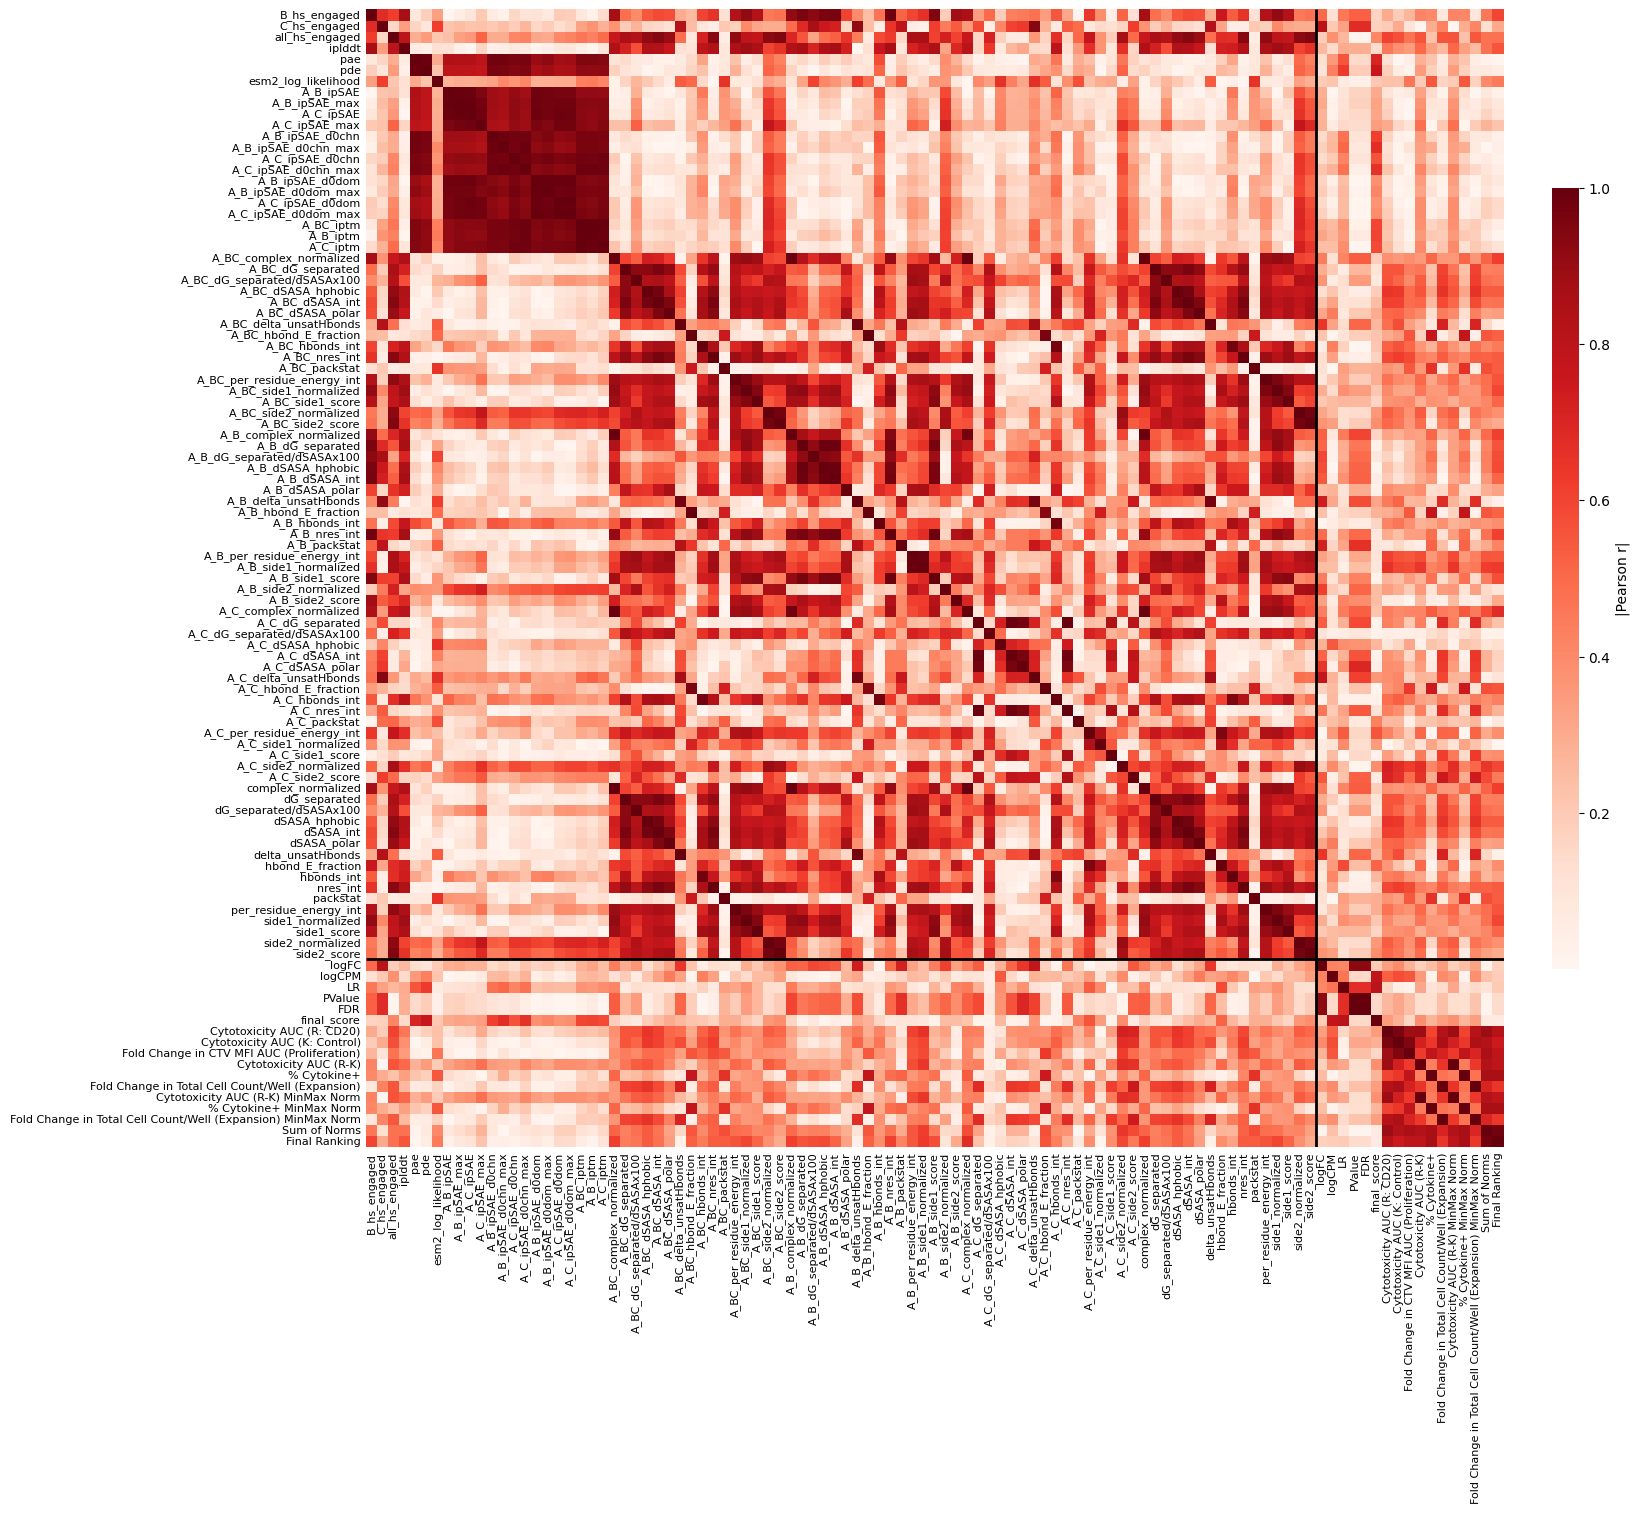

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- load ---
df = pd.read_csv("../data/master_data_top10_with_features_fixed.csv")

columns = [
    "B_hs_engaged","C_hs_engaged","all_hs_engaged","iplddt","pae","pde","esm2_log_likelihood",
    "A_B_ipSAE","A_B_ipSAE_max","A_C_ipSAE","A_C_ipSAE_max","A_B_ipSAE_d0chn","A_B_ipSAE_d0chn_max",
    "A_C_ipSAE_d0chn","A_C_ipSAE_d0chn_max","A_B_ipSAE_d0dom","A_B_ipSAE_d0dom_max","A_C_ipSAE_d0dom",
    "A_C_ipSAE_d0dom_max","A_BC_iptm","A_B_iptm","A_C_iptm","total_score","A_BC_complex_normalized",
    "A_BC_dG_cross","A_BC_dG_cross/dSASAx100","A_BC_dG_separated","A_BC_dG_separated/dSASAx100",
    "A_BC_dSASA_hphobic","A_BC_dSASA_int","A_BC_dSASA_polar","A_BC_delta_unsatHbonds","A_BC_hbond_E_fraction",
    "A_BC_hbonds_int","A_BC_nres_all","A_BC_nres_int","A_BC_packstat","A_BC_per_residue_energy_int",
    "A_BC_sc_value","A_BC_side1_normalized","A_BC_side1_score","A_BC_side2_normalized","A_BC_side2_score",
    "A_B_complex_normalized","A_B_dG_cross","A_B_dG_cross/dSASAx100","A_B_dG_separated","A_B_dG_separated/dSASAx100",
    "A_B_dSASA_hphobic","A_B_dSASA_int","A_B_dSASA_polar","A_B_delta_unsatHbonds","A_B_hbond_E_fraction",
    "A_B_hbonds_int","A_B_nres_all","A_B_nres_int","A_B_packstat","A_B_per_residue_energy_int","A_B_sc_value",
    "A_B_side1_normalized","A_B_side1_score","A_B_side2_normalized","A_B_side2_score","A_C_complex_normalized",
    "A_C_dG_cross","A_C_dG_cross/dSASAx100","A_C_dG_separated","A_C_dG_separated/dSASAx100","A_C_dSASA_hphobic",
    "A_C_dSASA_int","A_C_dSASA_polar","A_C_delta_unsatHbonds","A_C_hbond_E_fraction","A_C_hbonds_int","A_C_nres_all",
    "A_C_nres_int","A_C_packstat","A_C_per_residue_energy_int","A_C_sc_value","A_C_side1_normalized","A_C_side1_score",
    "A_C_side2_normalized","A_C_side2_score","complex_normalized","dG_cross","dG_cross/dSASAx100","dG_separated",
    "dG_separated/dSASAx100","dSASA_hphobic","dSASA_int","dSASA_polar","delta_unsatHbonds","hbond_E_fraction",
    "hbonds_int","nres_all","nres_int","packstat","per_residue_energy_int","sc_value","side1_normalized","side1_score",
    "side2_normalized","side2_score","logFC","logCPM","LR","PValue","FDR","final_score",
    "Cytotoxicity AUC (R: CD20)","Cytotoxicity AUC (K: Control)","Fold Change in CTV MFI AUC (Proliferation)",
    "Cytotoxicity AUC (R-K)","% Cytokine+","Fold Change in Total Cell Count/Well (Expansion)","Cytotoxicity AUC (R-K) MinMax Norm",
    "% Cytokine+ MinMax Norm","Fold Change in Total Cell Count/Well (Expansion) MinMax Norm","Sum of Norms","Final Ranking"
]

# measurements (put these at the end)
measurement_cols = [
    "logFC","logCPM","LR","PValue","FDR","final_score",
    "Cytotoxicity AUC (R: CD20)","Cytotoxicity AUC (K: Control)","Fold Change in CTV MFI AUC (Proliferation)",
    "Cytotoxicity AUC (R-K)","% Cytokine+","Fold Change in Total Cell Count/Well (Expansion)",
    "Cytotoxicity AUC (R-K) MinMax Norm","% Cytokine+ MinMax Norm",
    "Fold Change in Total Cell Count/Well (Expansion) MinMax Norm","Sum of Norms","Final Ranking"
]

# features = columns \ measurements (keep only those present)
feature_cols = [c for c in columns if c in df.columns and c not in measurement_cols]

# numeric only + drop constants
def _is_nonconstant_numeric(s: pd.Series) -> bool:
    if not pd.api.types.is_numeric_dtype(s):
        return False
    return pd.Series(s).replace([np.inf,-np.inf], np.nan).nunique(dropna=True) > 1

feature_cols = [c for c in feature_cols if _is_nonconstant_numeric(df[c])]
measurement_cols_present = [c for c in measurement_cols if c in df.columns and _is_nonconstant_numeric(df[c])]

all_cols = feature_cols + measurement_cols_present

# build numeric matrix
X = (df[all_cols]
     .apply(pd.to_numeric, errors="coerce")
     .replace([np.inf, -np.inf], np.nan))

# compute Pearson corr (pairwise complete obs)
corr = X.corr(method="pearson", min_periods=3)

# drop any all-NaN rows/cols (e.g., if everything missing after coercion)
valid = corr.notna().any(axis=1)
corr = corr.loc[valid, valid]

# make abs val on corr
corr = corr.abs()

# re-split count for separator
k = len([c for c in feature_cols if c in corr.index])
n = corr.shape[0]

# plot
fig_w = max(10, n * 0.16)
fig_h = fig_w
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

sns.heatmap(
    corr, cmap="Reds", square=True,
    cbar_kws={"label": "|Pearson r|", "shrink": 0.6, "fraction": 0.03, "pad": 0.04, "aspect": 30},
    xticklabels=True, yticklabels=True, ax=ax
)

# separator before measurements
if 0 < k < n:
    ax.vlines(k, 0, n, colors="black", lw=2)
    ax.hlines(k, 0, n, colors="black", lw=2)

# tidy ticks
for lbl in ax.get_xticklabels():
    lbl.set_fontsize(8)
for lbl in ax.get_yticklabels():
    lbl.set_fontsize(8)
ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.savefig("../results/pearson_heatmap_all_features.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
df

,team_x,submitted_id,team_sequence_count,global_id,sequence,B_hs_engaged,C_hs_engaged,all_hs_engaged,iplddt,pae,...,Cytotoxicity AUC (K: Control),Fold Change in CTV MFI AUC (Proliferation),Cytotoxicity AUC (R-K),% Cytokine+,Fold Change in Total Cell Count/Well (Expansion),Cytotoxicity AUC (R-K) MinMax Norm,% Cytokine+ MinMax Norm,Fold Change in Total Cell Count/Well (Expansion) MinMax Norm,Sum of Norms,Final Ranking
0,CAD Pro,seq372,372,1304,SSKSSRVVVISSLSSLLFFVLLLAAAMQQQCQQKYYELLYTTTTTT...,0.069767,0.093023,0.081395,0.633664,8.129427,...,119.6,3.58,-58.51,0.57,2.99,-0.83,-0.05,0.03,-0.85,9
1,Perez Lab Gators,design_108,108,1506,SLEERRKELKEKVEAGELNYWEIMYEAMKLMIESGAPIEHLEYATN...,0.441860,0.046512,0.244186,0.805831,11.596670,...,227.6,9.00,52.90,22.63,5.95,0.67,1.04,0.29,1.99,1
2,LBM,sequence16333,28,1892,SKVDRRRKANEAYSAAYAALEKERAEATNEANALAAEAEKASEAER...,0.441860,0.093023,0.267442,0.820229,12.597118,...,118.0,3.38,-44.53,1.07,3.01,-0.64,-0.02,0.03,-0.63,8
3,Nucleate UK London,MC-dimer-SolMPNN-35,136,2383,DLLEKLLSLASFGDPEVRARMEALPPEEKKNSPEYQEYEQRRRSEI...,0.395349,0.139535,0.267442,0.847583,16.402763,...,214.7,7.31,46.20,2.73,4.20,0.58,0.06,0.13,0.77,5
4,SNU LCDD,HL_RTX_183_84|-41.994,236,3494,MEKEIIIEVGEVKENGTIVLKGKTLDGGEVEEVEARSTYYGGNEKI...,0.069767,0.418605,0.244186,0.717321,10.601098,...,267.4,10.95,17.90,7.40,5.68,0.20,0.29,0.26,0.75,6
5,SNU LCDD,HL_OBZ_262_88|-33.5018,460,3718,NLEKIAAFYRELGERLAAALRARYPERAAEIDARLAEFLALVEKML...,0.441860,0.139535,0.290698,0.788382,19.727791,...,254.2,11.29,23.40,10.00,5.64,0.27,0.42,0.26,0.95,4
6,Amigo Acids,AHOF_5th_seq178__9_dldesign_2.pdb,178,5300,GSWLQAALNIAEQIYKLGPEEQLQVLNDILEHIDSFTKEEAEALLV...,0.348837,0.116279,0.232558,0.769152,13.945880,...,260.7,13.37,11.70,34.83,4.86,0.12,1.64,0.19,1.95,2
7,Binding Illini,"T=0.1,",315,5624,FSTVNIHFFKETEDNTLEYIGAIYPKFNDTSINPKYKNKVKLSYDK...,0.116279,0.395349,0.255814,0.723374,17.100089,...,209.9,6.36,-13.20,3.37,5.94,-0.22,0.09,0.29,0.16,7
8,Schoeder Lab,206_CD20_3-33_120_dldesign_11_af2pred_RFdif_PM...,206,5981,NAAAVGDLQAMARGTIEAATIDKETADKATKIMVEYAKANANSEGV...,0.441860,0.139535,0.290698,0.883442,3.061416,...,280.5,12.18,4.30,22.53,5.94,0.02,1.03,0.29,1.34,3


In [20]:
# exclude = ["Cytotoxicity AUC (R: CD20)","Cytotoxicity AUC (K: Control)","Fold Change in CTV MFI AUC (Proliferation)",
#     "Cytotoxicity AUC (R-K)","% Cytokine+","Fold Change in Total Cell Count/Well (Expansion)","Cytotoxicity AUC (R-K) MinMax Norm",
#     "% Cytokine+ MinMax Norm","Fold Change in Total Cell Count/Well (Expansion) MinMax Norm","Sum of Norms","Final Ranking"]

# now print the top correlations with "Sum of Norms"
target = "Sum of Norms"
# target = "Cytotoxicity AUC (R-K)"
if target in corr.index:
    target_corr = corr[target].drop(target, errors="ignore").sort_values(ascending=False)
    # drop exclude
    target_corr = target_corr.drop(exclude, errors="ignore")
    print(f"Top correlations with '{target}':")
    print(target_corr.head(20))

Top correlations with 'Sum of Norms':
A_C_side2_normalized           0.641547
A_B_side1_normalized           0.621656
A_C_side2_score                0.585375
A_C_complex_normalized         0.580328
A_BC_packstat                  0.576522
packstat                       0.576522
A_C_hbond_E_fraction           0.570896
A_BC_hbond_E_fraction          0.553811
A_B_hbond_E_fraction           0.553317
A_B_per_residue_energy_int     0.552390
A_BC_dSASA_hphobic             0.540501
dSASA_hphobic                  0.540501
nres_int                       0.522399
A_BC_nres_int                  0.522399
A_BC_complex_normalized        0.519148
complex_normalized             0.519148
A_B_complex_normalized         0.496481
per_residue_energy_int         0.486093
A_BC_per_residue_energy_int    0.486093
A_BC_dG_separated/dSASAx100    0.482335
Name: Sum of Norms, dtype: float64


In [21]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

def _safe(s):  # safe filenames
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(s))

# target = "Cytotoxicity AUC (R-K)"
target = "Sum of Norms"
exclude = ["Cytotoxicity AUC (R: CD20)","Cytotoxicity AUC (K: Control)","Fold Change in CTV MFI AUC (Proliferation)",
    "Cytotoxicity AUC (R-K)","% Cytokine+","Fold Change in Total Cell Count/Well (Expansion)","Cytotoxicity AUC (R-K) MinMax Norm",
    "% Cytokine+ MinMax Norm","Fold Change in Total Cell Count/Well (Expansion) MinMax Norm","Sum of Norms","Final Ranking"]

top_k = 20
out_dir = "../results/scatter_top_corr_vs_sum_of_norms"
os.makedirs(out_dir, exist_ok=True)

if target in corr.columns:
    target_corr = (corr[target]
                   .drop(labels=[target], errors="ignore")
                   .dropna()
                   .sort_values(ascending=False))
    top_features = [c for c in target_corr.index if c not in exclude][:top_k]

    for feature in top_features:
        x = pd.to_numeric(df[feature], errors="coerce")
        y = pd.to_numeric(df[target], errors="coerce")
        m = x.replace([np.inf, -np.inf], np.nan).notna() & y.replace([np.inf, -np.inf], np.nan).notna()
        x, y = x[m], y[m]

        if x.nunique() <= 1 or y.nunique() <= 1:
            r, p, n = np.nan, np.nan, len(x)
        else:
            r, p = pearsonr(x, y)
            n = len(x)

        fig, ax = plt.subplots(figsize=(5.5, 4))
        sns.regplot(x=x, y=y, ci=None,
                    scatter_kws={"alpha": 0.6, "s": 18},
                    line_kws={"linewidth": 1.5},
                    ax=ax)
        ax.set_xlabel(feature)
        ax.set_ylabel(target)
        ax.text(0.02, 0.98, f"r = {r:+.3f}\np = {p:.2e}\nn = {n}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=10, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none",))

        fname = os.path.join(out_dir, f"{_safe(target)}{_safe(feature)}.png")
        plt.tight_layout()
        plt.savefig(fname, dpi=300, bbox_inches="tight")
        plt.close(fig)

    print(f"Saved {len(top_features)} plots to {out_dir}")
else:
    print(f"'{target}' not found in corr.")

Saved 20 plots to ../results/scatter_top_corr_vs_sum_of_norms


In [22]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pandas.api.types import is_numeric_dtype
# from sklearn.feature_selection import mutual_info_regression

# # --- load ---
# df = pd.read_csv("../data/master_data_top10_with_features_fixed.csv")

# columns = [
#     "B_hs_engaged","C_hs_engaged","all_hs_engaged","iplddt","pae","pde","esm2_log_likelihood",
#     "A_B_ipSAE","A_B_ipSAE_max","A_C_ipSAE","A_C_ipSAE_max","A_B_ipSAE_d0chn","A_B_ipSAE_d0chn_max",
#     "A_C_ipSAE_d0chn","A_C_ipSAE_d0chn_max","A_B_ipSAE_d0dom","A_B_ipSAE_d0dom_max","A_C_ipSAE_d0dom",
#     "A_C_ipSAE_d0dom_max","A_BC_iptm","A_B_iptm","A_C_iptm","total_score","A_BC_complex_normalized",
#     "A_BC_dG_cross","A_BC_dG_cross/dSASAx100","A_BC_dG_separated","A_BC_dG_separated/dSASAx100",
#     "A_BC_dSASA_hphobic","A_BC_dSASA_int","A_BC_dSASA_polar","A_BC_delta_unsatHbonds","A_BC_hbond_E_fraction",
#     "A_BC_hbonds_int","A_BC_nres_all","A_BC_nres_int","A_BC_packstat","A_BC_per_residue_energy_int",
#     "A_BC_sc_value","A_BC_side1_normalized","A_BC_side1_score","A_BC_side2_normalized","A_BC_side2_score",
#     "A_B_complex_normalized","A_B_dG_cross","A_B_dG_cross/dSASAx100","A_B_dG_separated","A_B_dG_separated/dSASAx100",
#     "A_B_dSASA_hphobic","A_B_dSASA_int","A_B_dSASA_polar","A_B_delta_unsatHbonds","A_B_hbond_E_fraction",
#     "A_B_hbonds_int","A_B_nres_all","A_B_nres_int","A_B_packstat","A_B_per_residue_energy_int","A_B_sc_value",
#     "A_B_side1_normalized","A_B_side1_score","A_B_side2_normalized","A_B_side2_score","A_C_complex_normalized",
#     "A_C_dG_cross","A_C_dG_cross/dSASAx100","A_C_dG_separated","A_C_dG_separated/dSASAx100","A_C_dSASA_hphobic",
#     "A_C_dSASA_int","A_C_dSASA_polar","A_C_delta_unsatHbonds","A_C_hbond_E_fraction","A_C_hbonds_int","A_C_nres_all",
#     "A_C_nres_int","A_C_packstat","A_C_per_residue_energy_int","A_C_sc_value","A_C_side1_normalized","A_C_side1_score",
#     "A_C_side2_normalized","A_C_side2_score","complex_normalized","dG_cross","dG_cross/dSASAx100","dG_separated",
#     "dG_separated/dSASAx100","dSASA_hphobic","dSASA_int","dSASA_polar","delta_unsatHbonds","hbond_E_fraction",
#     "hbonds_int","nres_all","nres_int","packstat","per_residue_energy_int","sc_value","side1_normalized","side1_score",
#     "side2_normalized","side2_score","logFC","logCPM","LR","PValue","FDR","final_score",
#     "Cytotoxicity AUC (R: CD20)","Cytotoxicity AUC (K: Control)","Fold Change in CTV MFI AUC (Proliferation)",
#     "Cytotoxicity AUC (R-K)","% Cytokine+","Fold Change in Total Cell Count/Well (Expansion)","Cytotoxicity AUC (R-K) MinMax Norm",
#     "% Cytokine+ MinMax Norm","Fold Change in Total Cell Count/Well (Expansion) MinMax Norm","Sum of Norms","Final Ranking"
# ]

# # put these at the end
# measurement_cols = [
#     "logFC","logCPM","LR","PValue","FDR","final_score",
#     "Cytotoxicity AUC (R: CD20)","Cytotoxicity AUC (K: Control)","Fold Change in CTV MFI AUC (Proliferation)",
#     "Cytotoxicity AUC (R-K)","% Cytokine+","Fold Change in Total Cell Count/Well (Expansion)",
#     "Cytotoxicity AUC (R-K) MinMax Norm","% Cytokine+ MinMax Norm",
#     "Fold Change in Total Cell Count/Well (Expansion) MinMax Norm","Sum of Norms","Final Ranking"
# ]

# # numeric + non-constant
# def _ok(col):
#     s = df[col] if col in df.columns else None
#     if s is None or not is_numeric_dtype(s):
#         return False
#     s = pd.to_numeric(s, errors="coerce").replace([np.inf,-np.inf], np.nan)
#     return s.nunique(dropna=True) > 1

# feature_cols = [c for c in columns if c not in measurement_cols and _ok(c)]
# measurement_cols_present = [c for c in measurement_cols if _ok(c)]
# all_cols = feature_cols + measurement_cols_present

# # numeric matrix w/ NaNs handled (fill to avoid row dropping per-target)
# X = (df[all_cols]
#      .apply(pd.to_numeric, errors="coerce")
#      .replace([np.inf, -np.inf], np.nan)
#      .fillna(0.0))

# # MI vs each target col
# mi_list = []
# for tgt in all_cols:
#     y = X[tgt].values
#     # skip if constant (already filtered, but safe)
#     if np.nanstd(y) == 0:
#         mi = np.full(len(all_cols), np.nan)
#     else:
#         mi = mutual_info_regression(X[all_cols], y, random_state=0, n_neighbors=5)
#     mi_list.append(pd.Series(mi, index=all_cols, name=tgt))

# mi_matrix = pd.concat(mi_list, axis=1)

# # symmetrize + zero diagonal
# mi_matrix = (mi_matrix + mi_matrix.T) / 2.0
# np.fill_diagonal(mi_matrix.values, 0.0)

# # drop all-NaN rows/cols (just in case)
# valid = mi_matrix.notna().any(axis=1)
# mi_matrix = mi_matrix.loc[valid, valid]

# # plot
# n = mi_matrix.shape[0]
# fig_w = max(10, n * 0.16)
# fig_h = fig_w
# fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# vmax = np.nanquantile(mi_matrix.values[np.isfinite(mi_matrix.values)], 0.99)
# sns.heatmap(
#     mi_matrix, cmap="Blues", vmin=0, vmax=2, square=True,
#     cbar_kws={"label": "Mutual Information", "shrink": 0.6, "fraction": 0.03, "pad": 0.04, "aspect": 30},
#     xticklabels=True, yticklabels=True, ax=ax
# )

# # separator before measurements
# k = len([c for c in feature_cols if c in mi_matrix.index])
# if 0 < k < n:
#     ax.vlines(k, 0, n, colors="black", lw=2)
#     ax.hlines(k, 0, n, colors="black", lw=2)

# # tidy ticks
# for lbl in ax.get_xticklabels():
#     lbl.set_fontsize(8)
# for lbl in ax.get_yticklabels():
#     lbl.set_fontsize(8)
# ax.tick_params(axis="x", length=0)
# ax.tick_params(axis="y", length=0)

# plt.tight_layout()
# plt.savefig("../results/mi_heatmap_all_features_continuous.png", dpi=300, bbox_inches="tight")
# plt.show()